# 03 — CNN para Classificação de EEG

Este notebook treina uma CNN 2D para classificar estados mentais a partir das features espectrais do EEG.

A entrada da rede é uma grade **5×5×N**, onde:
- **Linhas** = canais EEG (AF3, AF4, T7, T8, Pz)
- **Colunas** = bandas de frequência (Theta, Alpha, Beta, Gamma, ...)
- **Profundidade (canais CNN)** = N frames temporais consecutivos empilhados

O janelamento temporal empilha N=3 amostras consecutivas como canais, dando à CNN contexto de como o sinal EEG evoluiu ao longo do tempo — principal diferença em relação à versão sem contexto temporal.

Os dados utilizados são os gerados pelo notebook `02_preprocessamento_base.ipynb` com `split_strategy="random"`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from src.models.cnn import CNNConfig, train_cnn

## Carregar dados pré-processados

In [3]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

X_train = np.load(PROCESSED_DIR / "X_train_base.npy")
X_test  = np.load(PROCESSED_DIR / "X_test_base.npy")
y_train = np.load(PROCESSED_DIR / "y_train.npy")
y_test  = np.load(PROCESSED_DIR / "y_test.npy")

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (68388, 25)
X_test:  (17097, 25)
y_train: (68388,)
y_test:  (17097,)


## Treinar o modelo

In [4]:
config = CNNConfig()

result = train_cnn(X_train, y_train, X_test, y_test, config)

Epoch 1/100


  1/428 ━━━━━━━━━━━━━━━━━━━━ 4:40 657ms/step - accuracy: 0.3281 - loss: 1.8170

 25/428 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3404 - loss: 1.4817    

 49/428 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3441 - loss: 1.4086

 74/428 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3492 - loss: 1.3615

...

345/428 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7295 - loss: 0.6016

370/428 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7295 - loss: 0.6016

395/428 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7295 - loss: 0.6015

419/428 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7295 - loss: 0.6015

428/428 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7299 - loss: 0.6001 - val_accuracy: 0.7337 - val_loss: 0.6065 - learning_rate: 1.5000e-04


## Curvas de aprendizado

Os gráficos abaixo mostram como a loss e a acurácia evoluíram durante o treino.
- A linha **azul** (train) representa o desempenho nos dados de treino.
- A linha **laranja** (val) representa o desempenho nos dados de validação (20% do treino).

Se as duas linhas ficarem muito separadas, o modelo está decorando os dados de treino (overfitting).

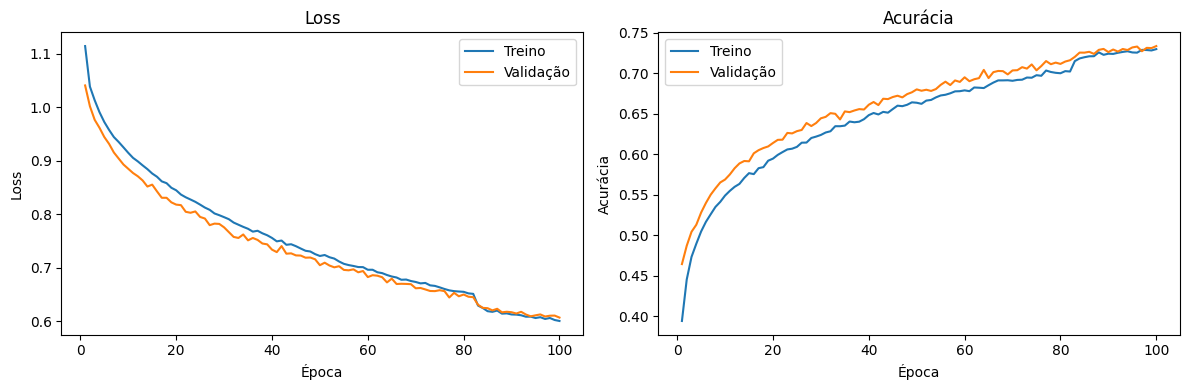

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_ran = range(1, len(result.history["loss"]) + 1)

ax1.plot(epochs_ran, result.history["loss"], label="Treino")
ax1.plot(epochs_ran, result.history["val_loss"], label="Validação")
ax1.set_title("Loss")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(epochs_ran, result.history["accuracy"], label="Treino")
ax2.plot(epochs_ran, result.history["val_accuracy"], label="Validação")
ax2.set_title("Acurácia")
ax2.set_xlabel("Época")
ax2.set_ylabel("Acurácia")
ax2.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "cnn_learning_curves.png", dpi=150)
plt.show()

## Resultado no conjunto de teste

In [6]:
print(f"Loss no teste:     {result.test_loss:.4f}")
print(f"Acurácia no teste: {result.test_accuracy:.4f} ({result.test_accuracy * 100:.2f}%)")

Loss no teste:     0.6134
Acurácia no teste: 0.7270 (72.70%)


## Matriz de confusão

Mostra quantas amostras de cada classe foram classificadas corretamente e quais foram confundidas com outras classes.

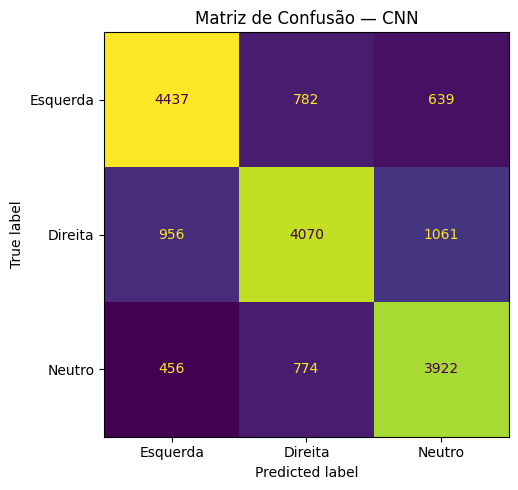

In [7]:
cm = confusion_matrix(result.y_test, result.y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Esquerda", "Direita", "Neutro"])
disp.plot(ax=ax, colorbar=False)
ax.set_title("Matriz de Confusão — CNN")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "cnn_confusion_matrix.png", dpi=150)
plt.show()

## Relatório de classificação

- **Precision**: de tudo que o modelo disse ser classe X, quantos eram de fato classe X.
- **Recall**: de todas as amostras da classe X, quantas o modelo acertou.
- **F1-score**: média harmônica entre precision e recall — a métrica mais equilibrada para comparar modelos.

In [8]:
print(classification_report(result.y_test, result.y_pred, target_names=["Esquerda", "Direita", "Neutro"]))

              precision    recall  f1-score   support

    Esquerda       0.76      0.76      0.76      5858
     Direita       0.72      0.67      0.69      6087
      Neutro       0.70      0.76      0.73      5152

    accuracy                           0.73     17097
   macro avg       0.73      0.73      0.73     17097
weighted avg       0.73      0.73      0.73     17097



## Salvar modelo

In [9]:
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

result.model.save(MODELS_DIR / "cnn_model.keras")
print("Modelo salvo em outputs/models/cnn_model.keras")

Modelo salvo em outputs/models/cnn_model.keras
